EDA 
tujuan: Menjawab seluruh Business Questions yang telah kita susun sebelumnya menggunakan visualisasi dan analisis data

1. Dataset Overview
2. Applicant Profile
3. Loan Analysis
4. Credit Risk Analysis
5. Correlation Analysis
6. Executive Summary

In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

df = pd.read_csv("../data/cleaned/cleaned_risk_dataset.csv")

In [6]:
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

Rows    : 32409
Columns : 12


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
person_age,32409.0,27.730754,6.210445,20.00,23.00,26.00,30.00,94.00
person_income,32409.0,65894.277053,52517.869973,4000.00,38500.00,55000.00,79200.00,2039784.00
person_emp_length,32409.0,4.761424,3.983757,0.00,2.00,4.00,7.00,41.00
loan_amnt,32409.0,9592.486655,6320.885127,500.00,5000.00,8000.00,12250.00,35000.00
loan_int_rate,32409.0,11.014512,3.083104,5.42,8.49,10.99,13.11,23.22
loan_status,32409.0,0.218705,0.413374,0.00,0.00,0.00,0.00,1.00
loan_percent_income,32409.0,0.170248,0.106785,0.00,0.09,0.15,0.23,0.83
cb_person_cred_hist_length,32409.0,5.811194,4.057899,2.00,3.00,4.00,8.00,30.00


In [8]:
loan_status = (
    df["loan_status"]
    .value_counts()
    .rename(index={0:"Non Default",1:"Default"})
)

loan_status

loan_status
Non Default    25321
Default         7088
Name: count, dtype: int64

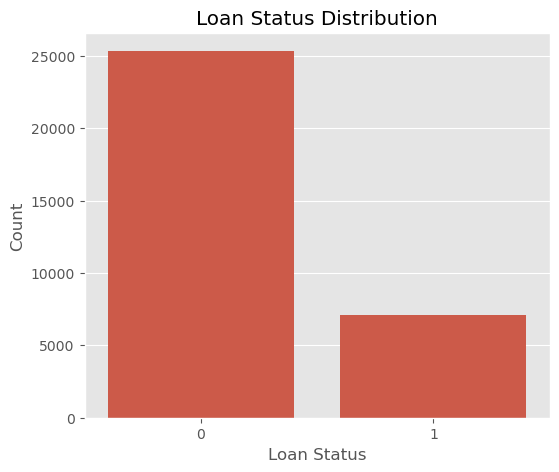

In [9]:
# Visualisasi loan status
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="loan_status"
)

plt.title("Loan Status Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Count")

plt.show()

insight: Mayoritas peminjam berhasil melunasi pinjaman, namun masih terdapat sejumlah nasabah yang mengalami gagal bayar sehingga perlu dilakukan analisis lebih lanjut mengenai karakteristik kelompok tersebut

In [ ]:
# Aplicant Profile
# : Siapa sebenarnya peminjam perusahaan ini?

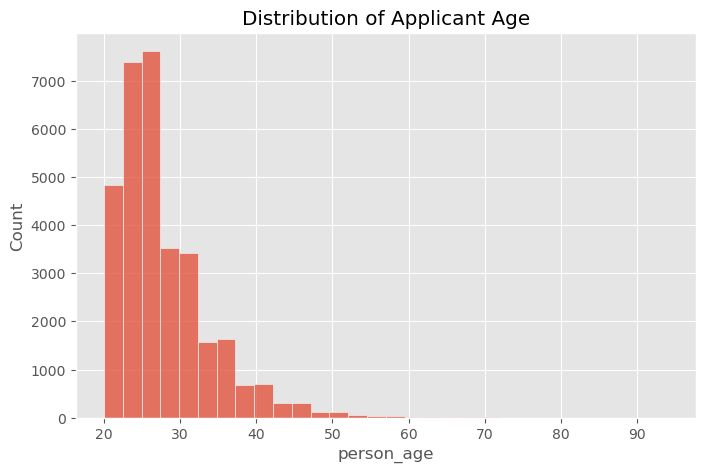

In [10]:
# Age Distribution
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="person_age",
    bins=30
)

plt.title("Distribution of Applicant Age")

plt.show()

insight: umur yang paling banyak meminjam uang direntang 20-30 (didominasi usia produktif)

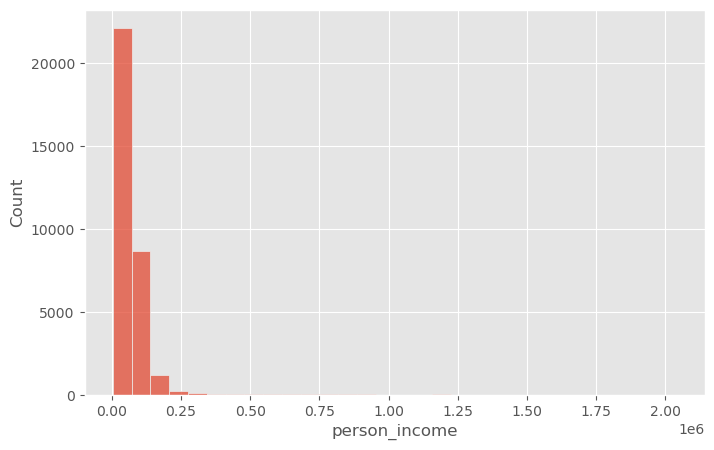

In [11]:
# income distribution
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="person_income",
    bins=30
)

plt.show()

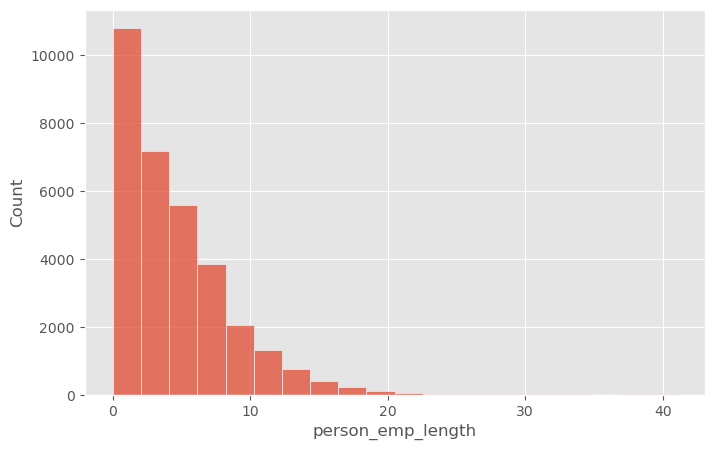

In [12]:
# Employment Length
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="person_emp_length",
    bins=20
)

plt.show()

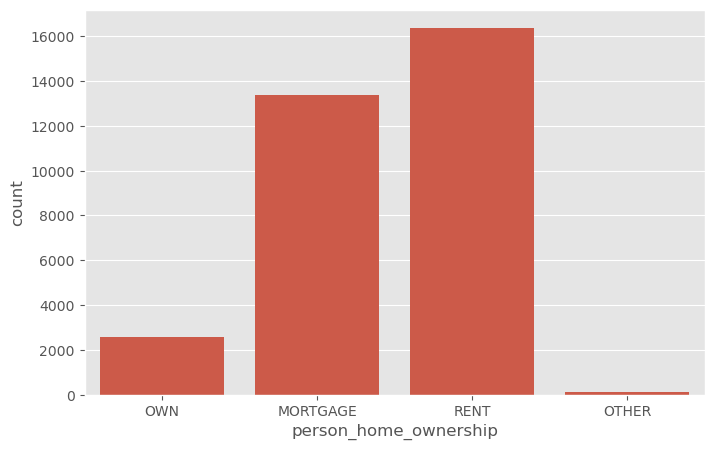

In [13]:
# Home Ownership
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="person_home_ownership"
)

plt.show()

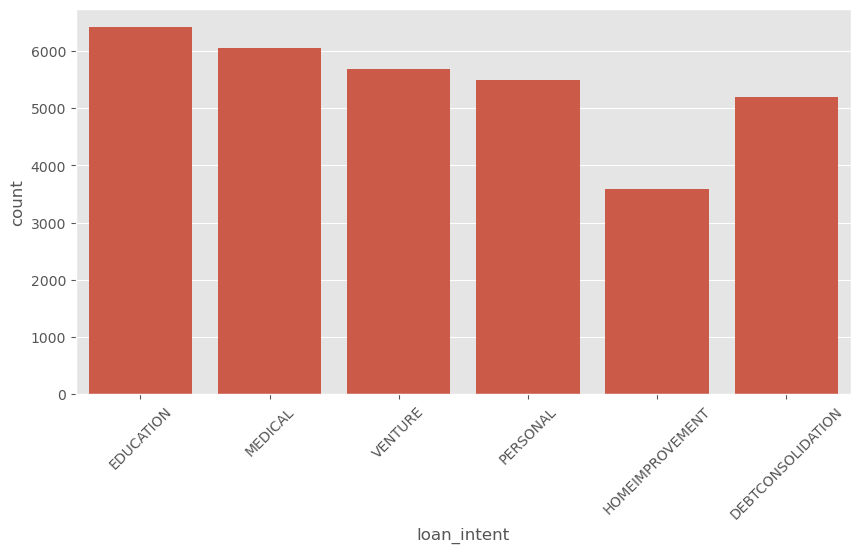

In [ ]:
# Loan Analysis (analisis pinjaman)
# a. Loan Intenr
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="loan_intent"
)

plt.xticks(rotation=45)

plt.show()

Tujuan pinjaman yang paling banyak adalah untuk biaya pendidikan

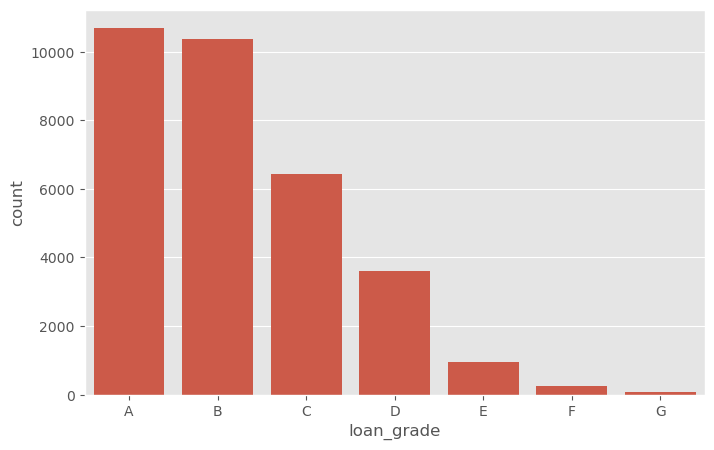

In [15]:
# b. Loan Grade
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="loan_grade",
    order=sorted(df["loan_grade"].unique())
)

plt.show()

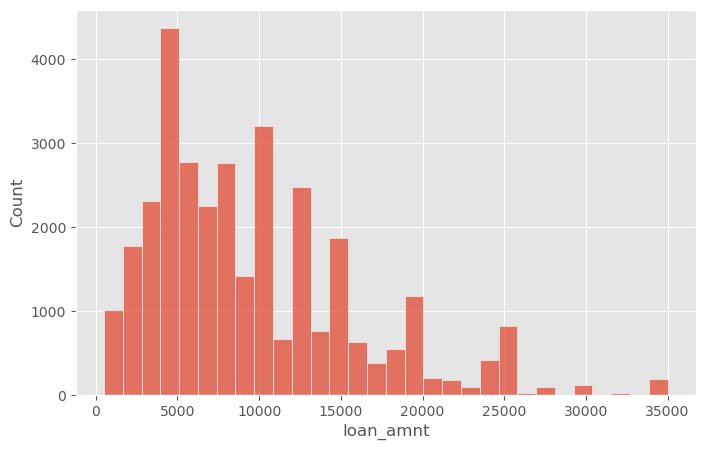

In [16]:
# c. Loan Amount
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="loan_amnt",
    bins=30
)

plt.show()

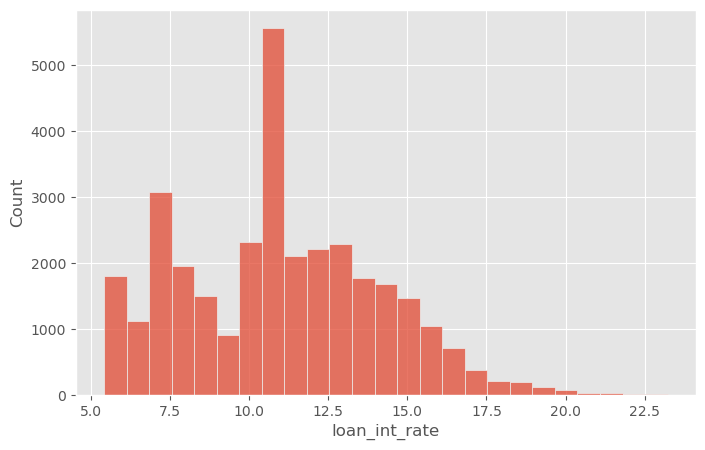

In [17]:
# d. Interest Rate
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="loan_int_rate",
    bins=25
)

plt.show()

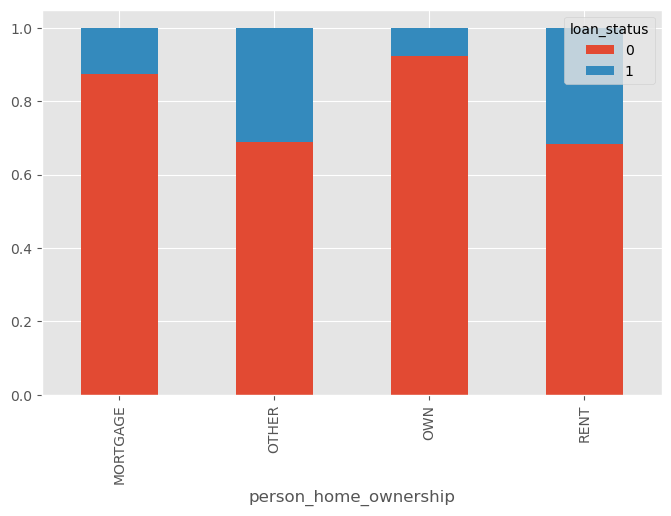

In [18]:
# Credit Risk Analysis
# a. Default by Home Ownership
risk_home = pd.crosstab(
    df["person_home_ownership"],
    df["loan_status"],
    normalize="index"
)

risk_home.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5)
)

plt.show()

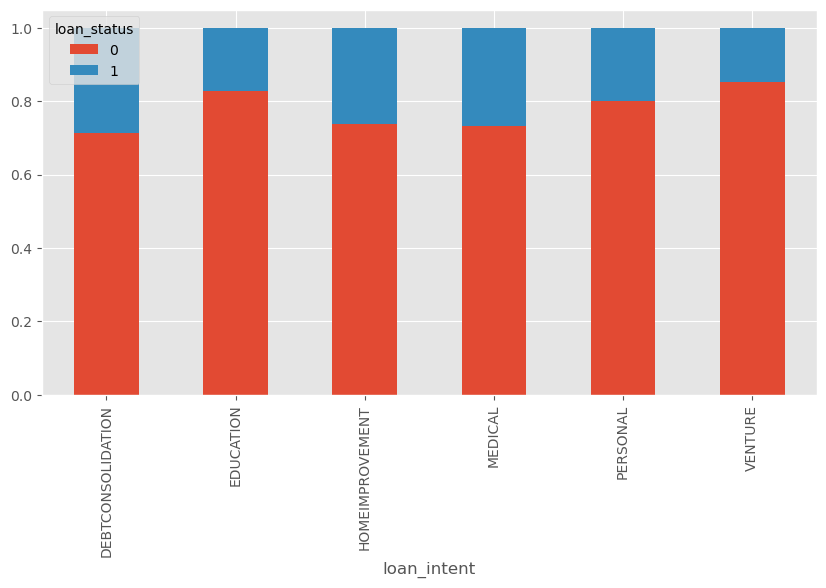

In [19]:
# b. Default Rate by Loan Intent
risk_intent = pd.crosstab(
    df["loan_intent"],
    df["loan_status"],
    normalize="index"
)

risk_intent.plot(
    kind="bar",
    stacked=True,
    figsize=(10,5)
)

plt.show()

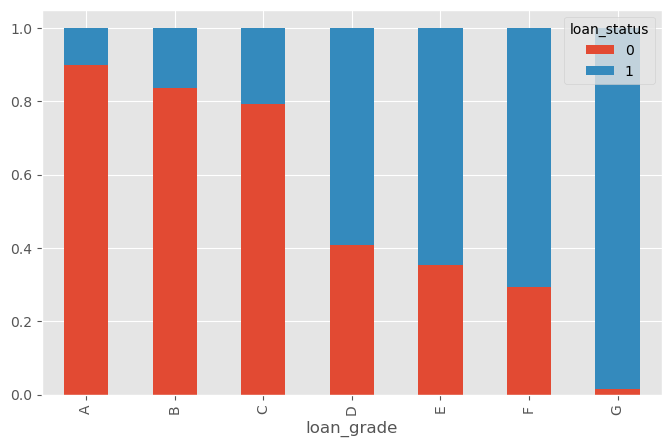

In [20]:
# c. Default Rate by Loan Grade
risk_grade = pd.crosstab(
    df["loan_grade"],
    df["loan_status"],
    normalize="index"
)

risk_grade.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5)
)

plt.show()

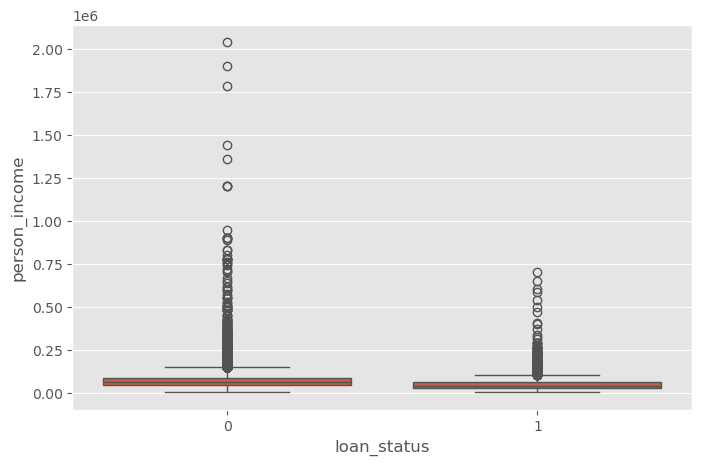

In [21]:
# d. Incomen vs Loan Status
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="loan_status",
    y="person_income"
)

plt.show()

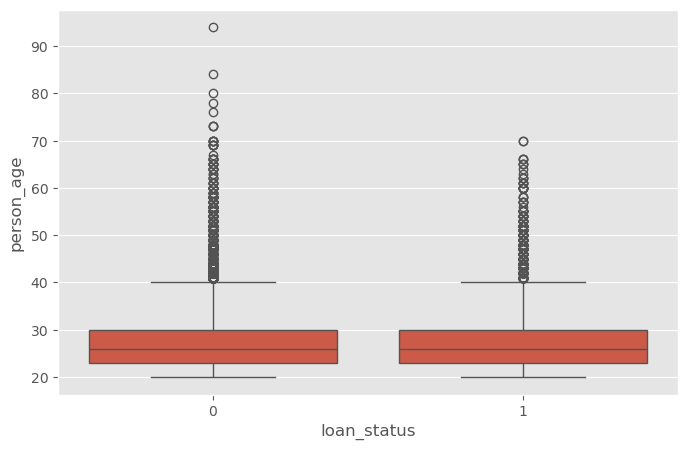

In [22]:
# f. Age vs Loan Status
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="loan_status",
    y="person_age"
)

plt.show()

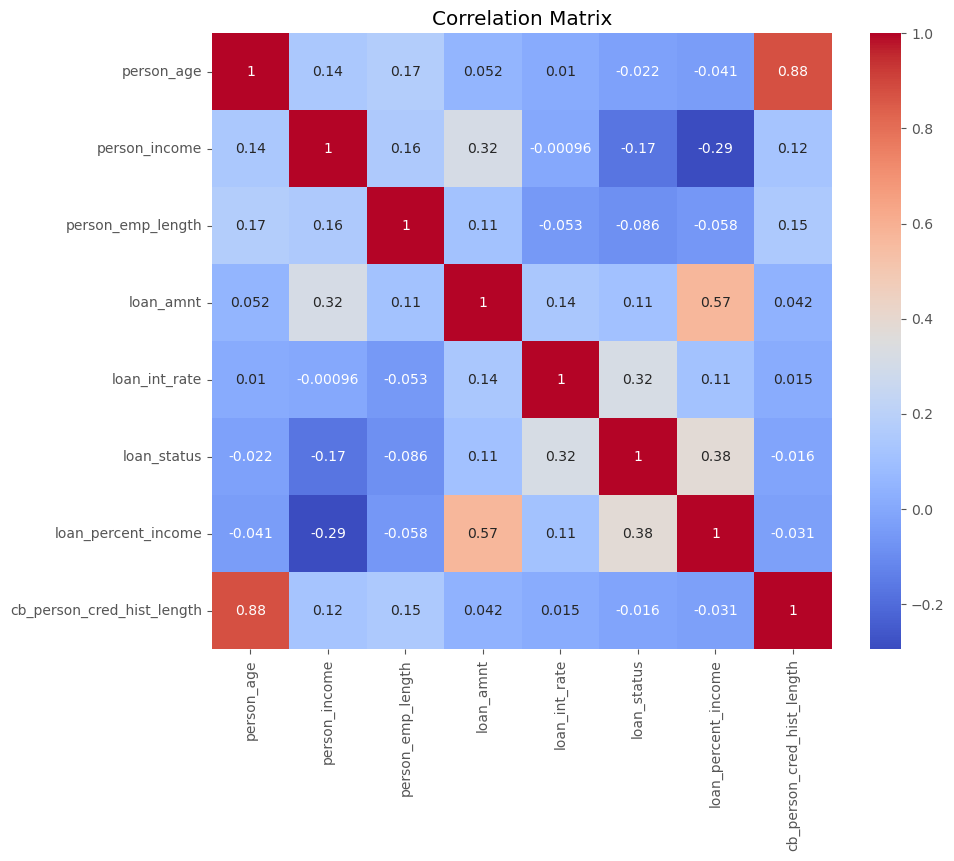

In [23]:
# Correlation Analysis
plt.figure(figsize=(10,8))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

# Executive Summary

## Key Findings

1. Mayoritas peminjam berada pada usia produktif.

2. Sebagian besar pinjaman diberikan untuk tujuan pendidikan

3. Grade pinjaman ... memiliki tingkat default tertinggi.

4. Kelompok dengan status kepemilikan rumah ... menunjukkan proporsi gagal bayar yang lebih tinggi.

5. Pendapatan yang lebih rendah cenderung berkaitan dengan risiko gagal bayar yang lebih tinggi.

6. Loan amount yang lebih besar tidak selalu menghasilkan tingkat gagal bayar yang lebih tinggi.

## Business Recommendations

- Tingkatkan evaluasi kredit pada kelompok berisiko tinggi.
- Terapkan proses verifikasi tambahan untuk profil tertentu.
- Gunakan karakteristik yang ditemukan sebagai pertimbangan dalam proses penilaian calon peminjam.